In [1]:
import re  
import pandas as pd 
from collections import defaultdict  # For word frequency
import logging  # Setting up the loggings to monitor gensim
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)
import missingno
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import plot_importance

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error, r2_score, auc
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesRegressor, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb
from xgboost.sklearn import XGBClassifier, XGBRegressor
from sklearn.naive_bayes import MultinomialNB, BernoulliNB 
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, SGDClassifier, LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

from vecstack import stacking
from vecstack import StackingTransformer

C:\Users\Common\Anaconda3\lib\site-packages\h5py\__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Data-Loading" data-toc-modified-id="Data-Loading-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Data Loading</a></span></li><li><span><a href="#Data-Exploration-&amp;-Preparation" data-toc-modified-id="Data-Exploration-&amp;-Preparation-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Data Exploration &amp; Preparation</a></span></li><li><span><a href="#Data-Preparation-&amp;-Feature-Engineering" data-toc-modified-id="Data-Preparation-&amp;-Feature-Engineering-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Preparation &amp; Feature Engineering</a></span></li><li><span><a href="#Imbalance-data" data-toc-modified-id="Imbalance-data-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Imbalance data</a></span></li><li><span><a href="#Machine-Learning-Models" data-toc-modified-id="Machine-Learning-Models-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Machine Learning Models</a></span></li><li><span><a href="#Stacking" data-toc-modified-id="Stacking-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Stacking</a></span></li><li><span><a href="#Final-Results" data-toc-modified-id="Final-Results-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Final Results</a></span></li><li><span><a href="#Random-Forest" data-toc-modified-id="Random-Forest-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Random Forest</a></span></li><li><span><a href="#XGBoost" data-toc-modified-id="XGBoost-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>XGBoost</a></span><ul class="toc-item"><li><span><a href="#XGBoost-Results" data-toc-modified-id="XGBoost-Results-9.1"><span class="toc-item-num">9.1&nbsp;&nbsp;</span>XGBoost Results</a></span></li></ul></li><li><span><a href="#ExtraTreesClassifier" data-toc-modified-id="ExtraTreesClassifier-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>ExtraTreesClassifier</a></span><ul class="toc-item"><li><span><a href="#ExtraTreesClassifier-Results" data-toc-modified-id="ExtraTreesClassifier-Results-10.1"><span class="toc-item-num">10.1&nbsp;&nbsp;</span>ExtraTreesClassifier Results</a></span></li></ul></li></ul></div>

# Data Loading

In [2]:
url = "bank-marketing.csv"
df = pd.read_csv(url)
# Dataset is now stored in a Pandas Dataframe

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Data Exploration & Preparation

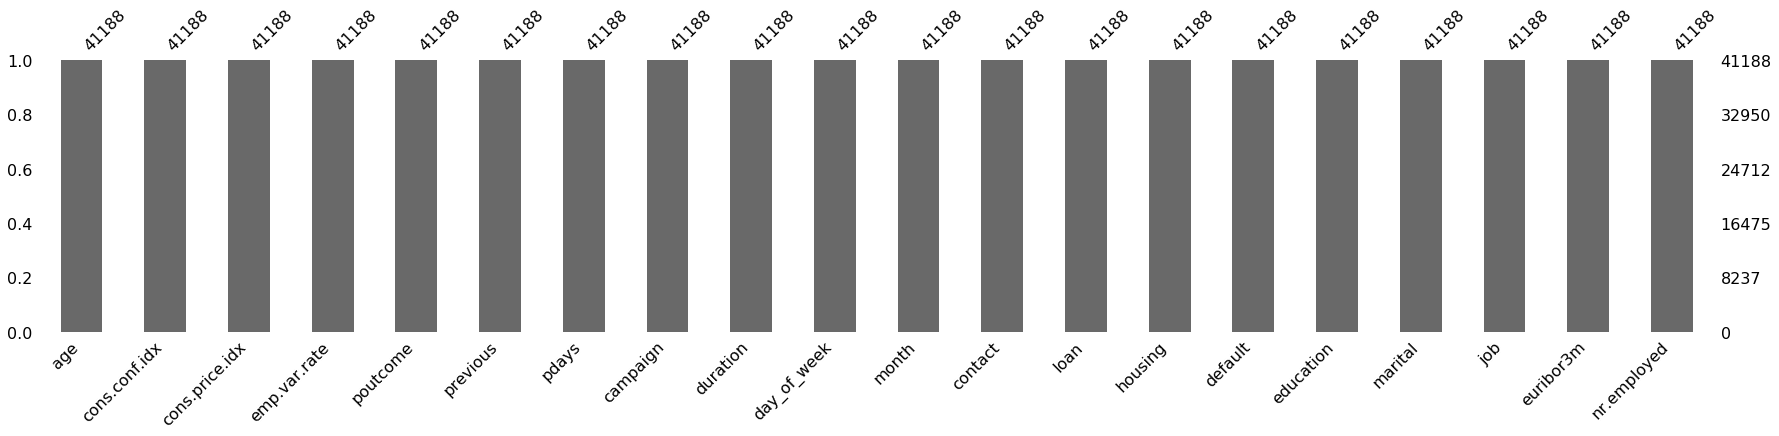

In [4]:
# Check the number of missing values
df_explore = df.copy()
df_explore.drop('y', axis=1, inplace=True)

missingno.bar(df_explore, sort='ascending', figsize = (30,5))

In [5]:
# Create buckets for age
df.loc[df['age'].between(17,21), 'age_range'] = 'legal_working'
df.loc[df['age'].between(22,31), 'age_range'] = 'post_legal'
df.loc[df['age'].between(32,41), 'age_range'] = 'pre-prime'
df.loc[df['age'].between(42,51), 'age_range'] = 'prime'
df.loc[df['age'].between(52,61), 'age_range'] = 'post_prime'
df.loc[df['age'].between(62,66), 'age_range'] = 'pre_retirement'
df.loc[df['age'].between(67,76), 'age_range'] = 'retirement'
df.loc[df['age'].between(77,86), 'age_range'] = 'pension'
df.loc[df['age'] >= 87, 'age_range'] = 'golden'

In [7]:
#df=df.drop(['age'],axis=1)

In [6]:
print('\n'+'='*20 + ' Data Exploration ' + '='*20+'\n')
print('The dataset has',df.shape[0],'rows &', df.shape[1],'columns.\n')
print('Number of observation per class:\n',df.y.value_counts())
print('\nSum of null values per column:\n',df.isnull().sum())
print('\nData type per column:\n',df.dtypes)
print('\nNumber of unique values per column:\n')


==================== Data Exploration ====================

The dataset has 41188 rows & 22 columns.

Number of observation per class:
 no     36548
yes     4640
Name: y, dtype: int64

Sum of null values per column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
age_range         0
dtype: int64

Data type per column:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign           

In [7]:
features=df.columns.tolist()
nb_unique_val=[]
for feature in features:
    nb_unique_val.append(len(df[feature].unique()))
features=pd.DataFrame(features, columns=['features'])
nb_unique_val=pd.DataFrame(nb_unique_val, columns=['nb_unique_val'])
feature_unique_val=pd.concat([features,nb_unique_val],axis=1)
print(feature_unique_val,'\n')

          features  nb_unique_val
0              age             78
1              job             12
2          marital              4
3        education              8
4          default              3
5          housing              3
6             loan              3
7          contact              2
8            month             10
9      day_of_week              5
10        duration           1544
11        campaign             42
12           pdays             27
13        previous              8
14        poutcome              3
15    emp.var.rate             10
16  cons.price.idx             26
17   cons.conf.idx             26
18       euribor3m            316
19     nr.employed             11
20               y              2
21       age_range              9 



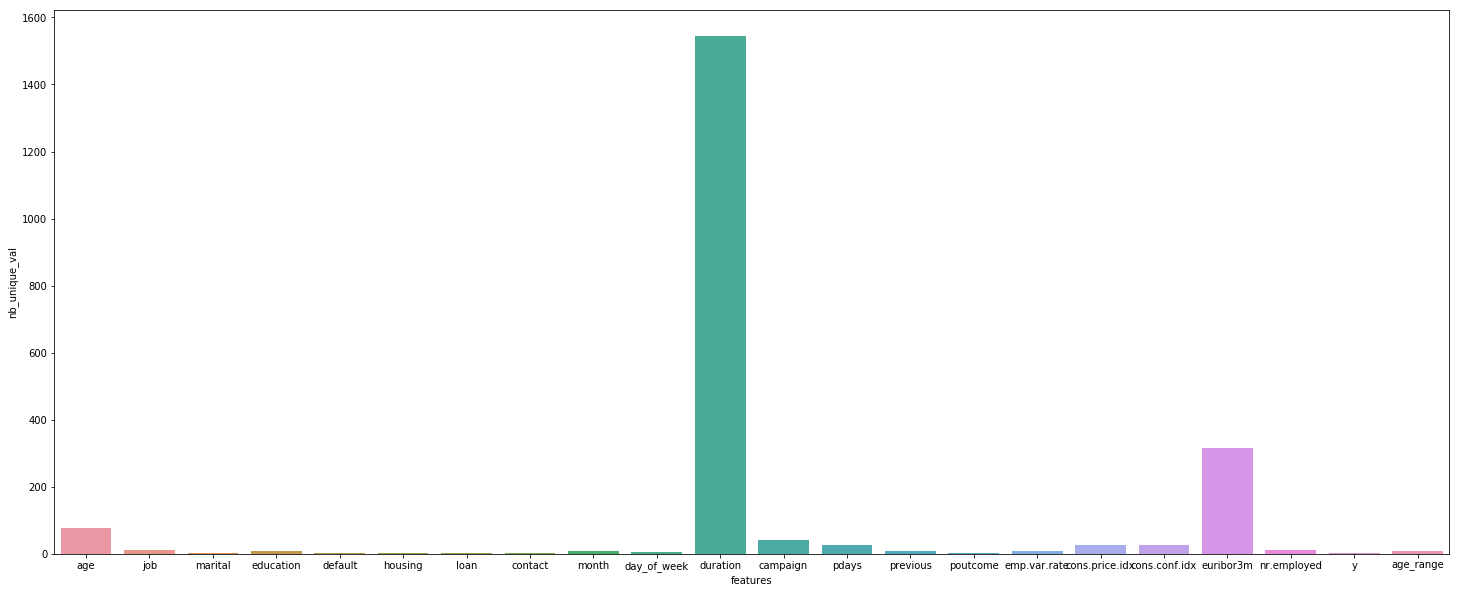

In [8]:
dim_unique_feature = (25, 10)
fig, ax = plt.subplots(figsize=dim_unique_feature)

sns.barplot(ax=ax, data = feature_unique_val
            ,x = 'features'
            ,y = 'nb_unique_val'
            )

In [9]:
# Describing all the Numerical Features
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
# Describing all the Categorical Features
df.describe(include=['O'])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y,age_range
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2,9
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no,pre-prime
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548,15716


y distribution
no     36548
yes     4640
Name: y, dtype: int64


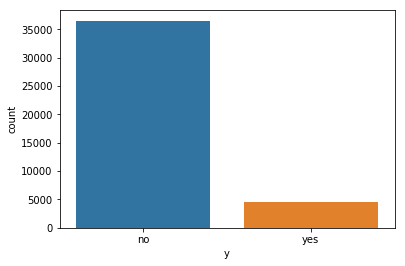

In [11]:
print('y distribution')
print(df.y.value_counts())
sns.countplot(x='y', data=df)
plt.show()

In [12]:
df_visualize_data = df.copy()
df_visualize_data = df_visualize_data.drop('y', axis=1)

C:\Users\Common\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
C:\Users\Common\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
C:\Users\Common\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
C:\Users\Common\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "
C:\Users\Common\Anaconda3\lib\site-packages\matplotlib\axes\_axe

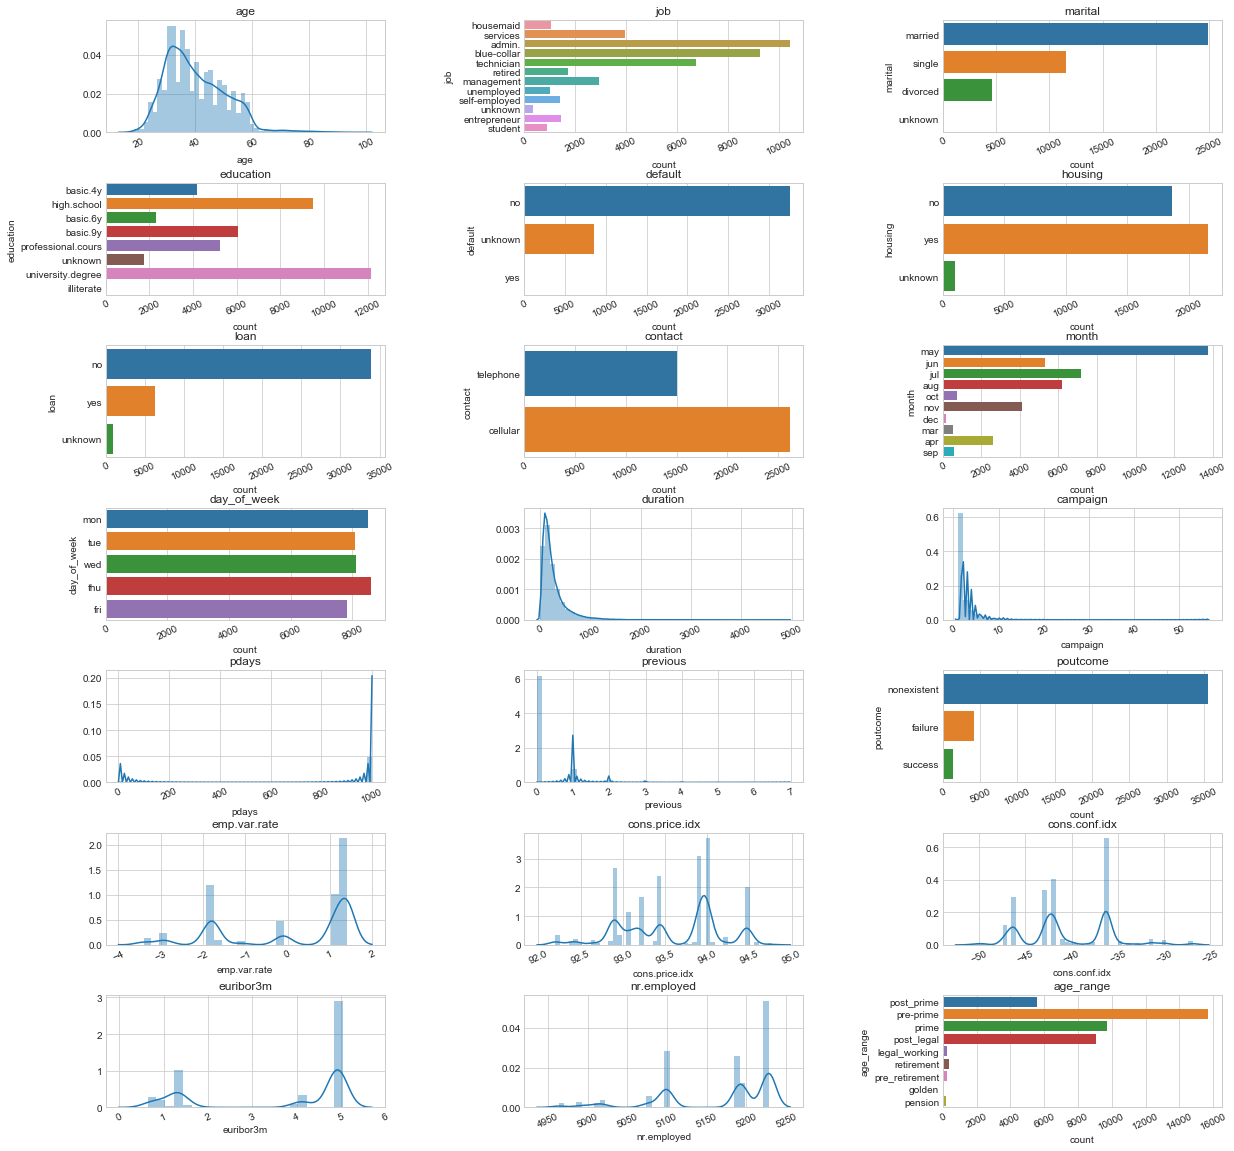

In [13]:
def plot_distribution(dataset, cols=5, width=20, height=15, hspace=0.2, wspace=0.5):
    plt.style.use('seaborn-whitegrid')
    fig = plt.figure(figsize=(width,height))
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=wspace, hspace=hspace)
    rows = math.ceil(float(dataset.shape[1]) / cols)
    for i, column in enumerate(dataset.columns):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.set_title(column)
        if dataset.dtypes[column] == np.object:
            g = sns.countplot(y=column, data=dataset)
            substrings = [s.get_text()[:18] for s in g.get_yticklabels()]
            g.set(yticklabels=substrings)
            plt.xticks(rotation=25)
        else:
            g = sns.distplot(dataset[column])
            plt.xticks(rotation=25)
    
plot_distribution(df_visualize_data, cols=3, width=20, height=20, hspace=0.45, wspace=0.5)

# Data Preparation & Feature Engineering

In [14]:
print('\n'+'='*20 + ' Data Preparation ' + '='*20+'\n')
df.columns = df.columns.str.replace('[^a-zA-Z0-9]', '_')
print('Non alphanumeric characters in columns name has been replaced by _ ')
    
df=df.drop(['duration'],axis=1)
print('Feature "duration" has been dropped as not relevent\n')


==================== Data Preparation ====================

Non alphanumeric characters in columns name has been replaced by _ 
Feature "duration" has been dropped as not relevent



In [15]:
df.loc[(df.y == 'yes'),'y'] = 1
df.loc[(df.y == 'no'),'y'] = 0

In [16]:
cat_features=['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome','age_range']
for cat_feature in cat_features:
    dummy_df=pd.get_dummies(df[cat_feature],drop_first=True)
    dummy_df.columns = [ cat_feature.strip()+'_'+str(col) for col in dummy_df.columns]
    df=pd.concat([df,dummy_df],axis=1)
df=df.drop(cat_features,axis=1)
print('Target variable as well as other categorical have been one hotencoded ')
print('List of columns names', df.columns,'\n')
print('The dataset has',df.shape[0],'rows &', df.shape[1],'columns.')


Target variable as well as other categorical have been one hotencoded 
List of columns names Index(['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_

In [17]:
# new dataframes.
df_transformed = pd.DataFrame() 

In [18]:
df_transformed = df.copy()
df_transformed = df_transformed.drop('y', axis=1)

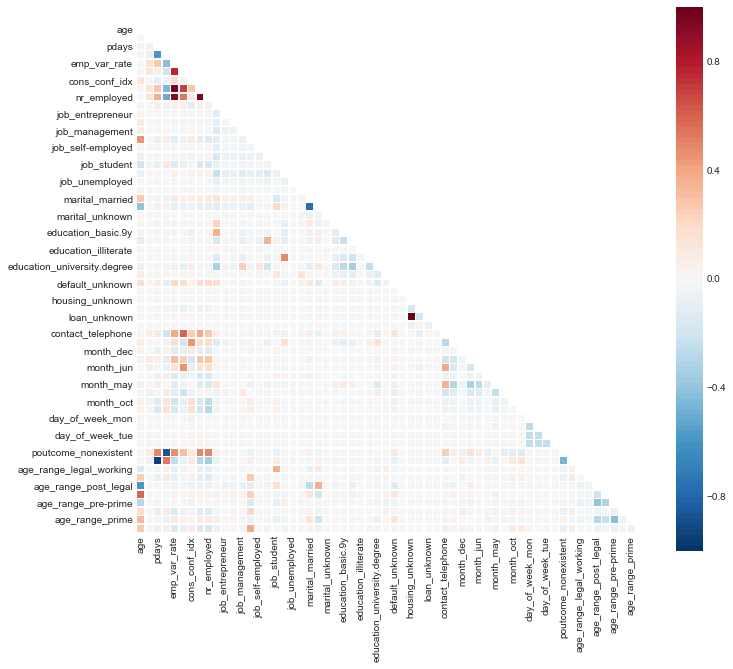

In [19]:
# correlation plot of one hot encoding dataset

plt.style.use('seaborn-whitegrid')
fig = plt.figure(figsize=(25,10)) 

plt.subplot(1, 2, 1)
# Generate a mask for the upper triangle
mask = np.zeros_like(df_transformed.corr(), dtype=np.bool)
mask = np.zeros_like(df_transformed.corr(), dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_transformed.corr(), 
            vmin=-1, vmax=1, 
            square=True, 
            cmap=sns.color_palette("RdBu_r", 100), 
            mask=mask, 
            linewidths=.5);

In [20]:
df_transformed.head()

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,job_blue-collar,...,poutcome_nonexistent,poutcome_success,age_range_legal_working,age_range_pension,age_range_post_legal,age_range_post_prime,age_range_pre-prime,age_range_pre_retirement,age_range_prime,age_range_retirement
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,0,1,0,0,0,0
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,0,1,0,0,0,0
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,0,0,1,0,0,0
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,0,0,1,0,0,0
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,0,1,0,0,0,0


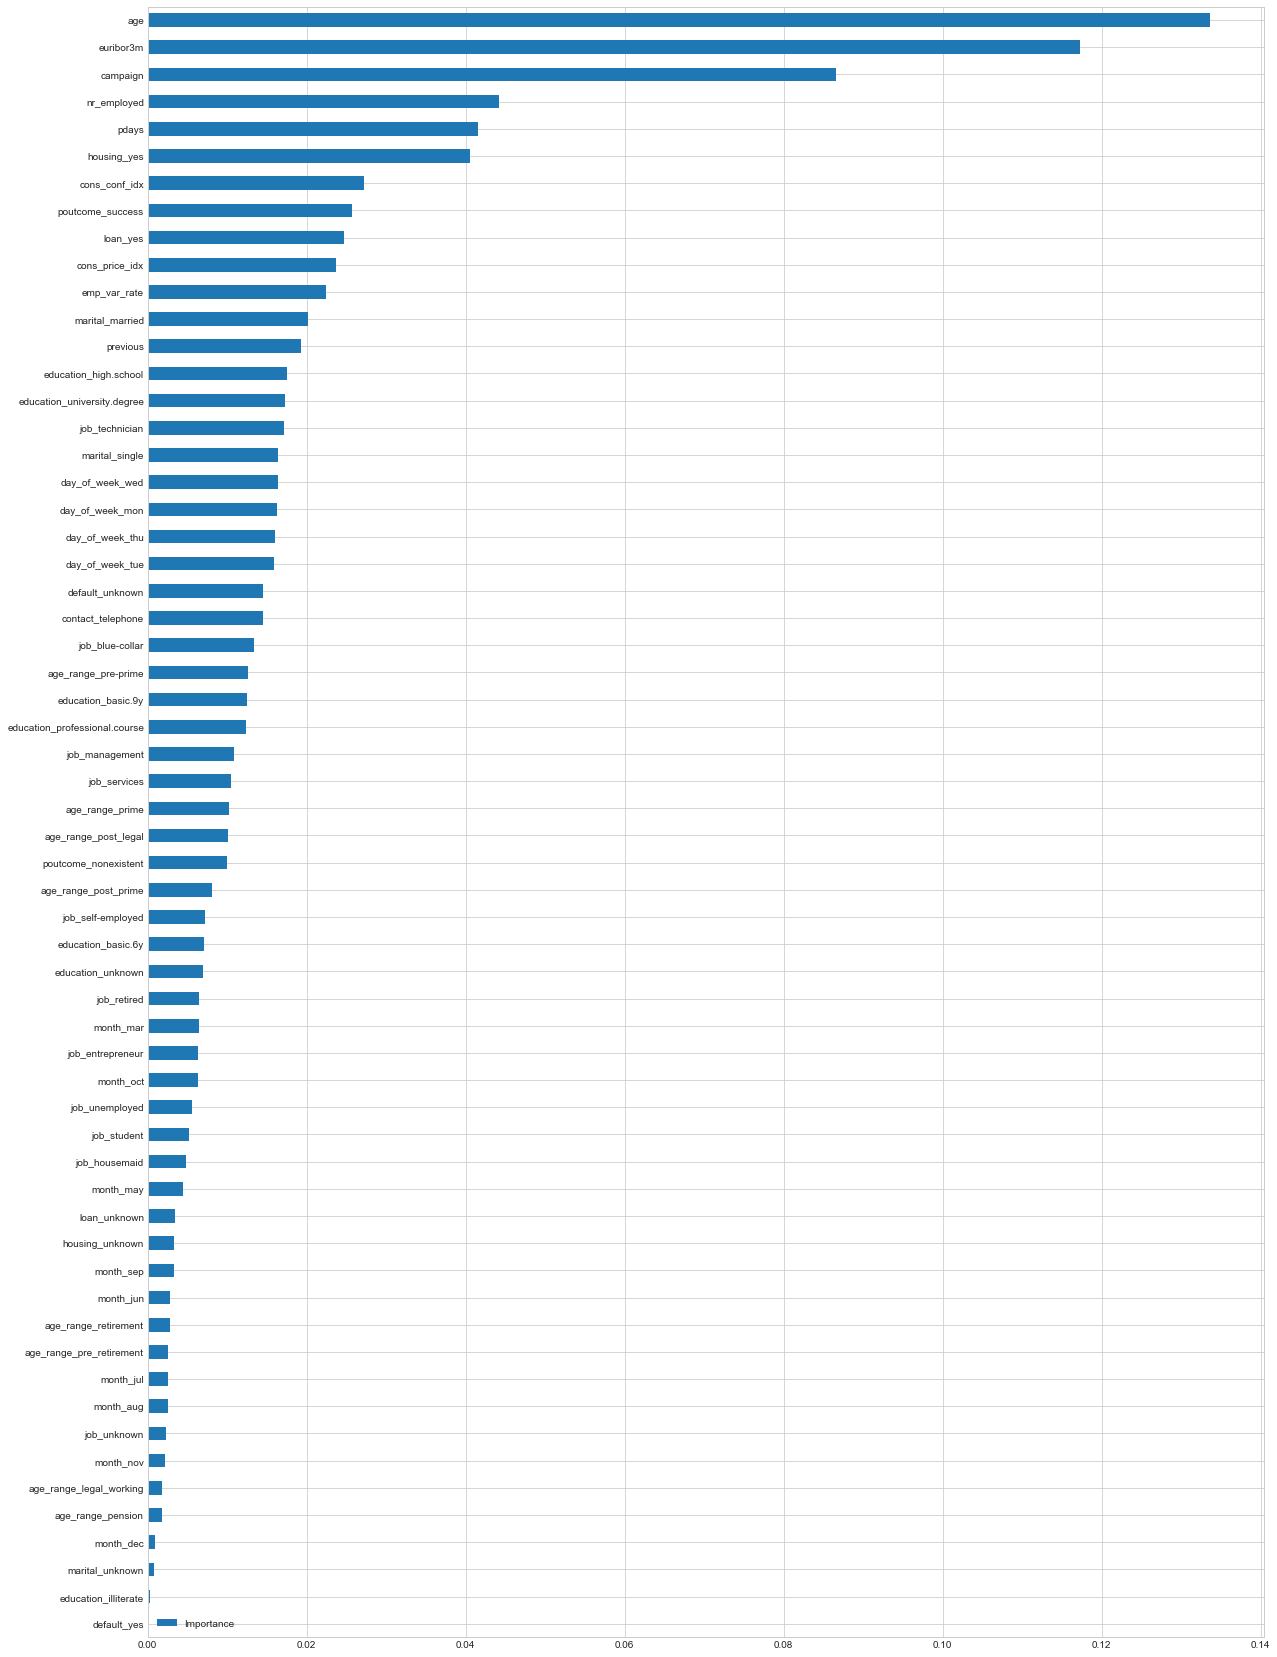

In [21]:
# Using Random Forest to gain an insight on Feature Importance
clf = RandomForestClassifier()
clf.fit(df_transformed, df['y'])

plt.style.use('seaborn-whitegrid')
importance = clf.feature_importances_
importance = pd.DataFrame(importance, index=df_transformed.columns, columns=["Importance"])
importance.sort_values(by='Importance', ascending=True).plot(kind='barh', figsize=(20,len(importance)/2));

In [22]:
#Numeric feature normalisation
#feature previous as been considered as it has only seven distinct discrete values
sc = StandardScaler()
numerical = ['pdays','campaign','emp_var_rate','cons_price_idx', 'cons_conf_idx','previous', 'euribor3m', 'nr_employed','age']
df_sc = df.copy()
df_sc[numerical] = sc.fit_transform(df_sc[numerical])

In [23]:
df_sc.head()

,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,...,poutcome_nonexistent,poutcome_success,age_range_legal_working,age_range_pension,age_range_post_legal,age_range_post_prime,age_range_pre-prime,age_range_pre_retirement,age_range_prime,age_range_retirement
0,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,...,1,0,0,0,0,1,0,0,0,0
1,1.628993,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,...,1,0,0,0,0,1,0,0,0,0
2,-0.290186,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,...,1,0,0,0,0,0,1,0,0,0
3,-0.002309,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,...,1,0,0,0,0,0,1,0,0,0
4,1.533034,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,0,...,1,0,0,0,0,1,0,0,0,0


In [24]:
df_sc.columns

Index(['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success'

# Imbalance data

In [26]:
X=df_sc.drop(['y'],axis=1)
y=df_sc['y']
y.value_counts()

0    36548
1     4640
Name: y, dtype: int64

In [27]:
# split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=10,stratify=y)
print(X_train.shape)
print(X_test.shape)

(32950, 60)
(8238, 60)


In [28]:
clf = DecisionTreeClassifier(random_state=10)
clf.fit(X_train, y_train)
print('accuracy on training data: ', clf.score(X_train, y_train))
print('accuracy on testing data: ',accuracy_score(y_test, clf.predict(X_test)))

class_report=classification_report(y_test, clf.predict(X_test))
print('\nClassification report for Decision Tree alogorithm: \n')
print(class_report)

accuracy on training data:  0.9950227617602428
accuracy on testing data:  0.8396455450352027

Classification report for Decision Tree alogorithm: 

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      7310
           1       0.31      0.35      0.33       928

    accuracy                           0.84      8238
   macro avg       0.61      0.62      0.62      8238
weighted avg       0.85      0.84      0.84      8238



In [29]:
# random under-sampling
rus = RandomUnderSampler(random_state=10)
X_RUS, y_RUS = rus.fit_sample(X, y)

# random over-sampling
ros = RandomOverSampler(random_state=10)
X_ROS, y_ROS = ros.fit_sample(X, y)

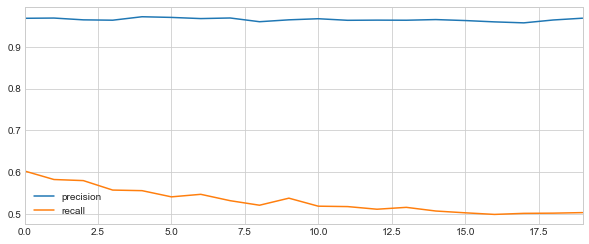

In [30]:
#searching for the best k for SMOTE sampling
precisions=[]
recalls=[]
for k in range(20):
    sm = SMOTE(k_neighbors=k+1,random_state=10)
    X_SMOTE, y_SMOTE = sm.fit_sample(X, y)
    X_SMOTE_train, X_SMOTE_test, y_SMOTE_train, y_SMOTE_test = train_test_split(X_SMOTE, y_SMOTE,test_size=0.2)
    report=precision_recall_fscore_support(y_SMOTE_test, clf.predict(X_SMOTE_test))
    precisions.append(report[0][1])
    recalls.append(report[1][1])
precision=pd.DataFrame(precisions, columns=['precision'])
recall=pd.DataFrame(recalls,columns=['recall'])
prec_recall=pd.concat([precision,recall],axis=1)

prec_recall.plot(figsize=(10, 4))
plt.legend()
plt.show()

In [31]:
# Synthetic Minority Over-Sampling Technique with k=2 (the best k value obtained with for loop above)
sm = SMOTE(k_neighbors=2,random_state=10)
X_SMOTE, y_SMOTE = sm.fit_sample(X, y)

In [32]:
print('\nNumber of samples per class for rus:\n', y_RUS.value_counts())
print('\nNumber of samples per class for ros:\n', y_ROS.value_counts())
print('\nNumber of samples per class for smote\n:',y_SMOTE.value_counts(),'\n')



Number of samples per class for rus:
 1    4640
0    4640
Name: y, dtype: int64

Number of samples per class for ros:
 1    36548
0    36548
Name: y, dtype: int64

Number of samples per class for smote
: 1    36548
0    36548
Name: y, dtype: int64 



In [33]:
X_RUS_train, X_RUS_test, y_RUS_train, y_RUS_test = train_test_split(X_RUS, y_RUS, test_size=0.2, random_state=10)
X_ROS_train, X_ROS_test, y_ROS_train, y_ROS_test = train_test_split(X_ROS, y_ROS, test_size=0.2, random_state=10)
X_SMOTE_train, X_SMOTE_test, y_SMOTE_train, y_SMOTE_test = train_test_split(X_SMOTE, y_SMOTE, test_size=0.2, random_state=10)

In [34]:
clf = DecisionTreeClassifier(random_state=10)

clf_rus = clf.fit(X_RUS_train, y_RUS_train)
print ("\nRUS - Train AUC : ",metrics.roc_auc_score(y_RUS_train, clf.predict(X_RUS_train)))
print ("RUS - Test AUC : ",metrics.roc_auc_score(y_RUS_test, clf.predict(X_RUS_test)))
class_report_rus=classification_report(y_RUS_test, clf.predict(X_RUS_test))
print('\nClassification report for Decision Tree, RUS sampling: \n')
print(class_report_rus)

clf_ros = clf.fit(X_ROS_train, y_ROS_train)
print ("\nROS - Train AUC : ",metrics.roc_auc_score(y_ROS_train, clf.predict(X_ROS_train)))
print ("ROS - Test AUC : ",metrics.roc_auc_score(y_ROS_test, clf.predict(X_ROS_test)))
class_report_ros=classification_report(y_ROS_test, clf.predict(X_ROS_test))
print('\nClassification report for Decision Tree, ROS sampling: \n')
print(class_report_ros)

clf_smote = clf.fit(X_SMOTE_train, y_SMOTE_train)
print ("\nSMOTE - Train AUC : ",metrics.roc_auc_score(y_SMOTE_train, clf.predict(X_SMOTE_train)))
print ("SMOTE - Test AUC : ",metrics.roc_auc_score(y_SMOTE_test, clf.predict(X_SMOTE_test)))
class_report_SMOTE=classification_report(y_SMOTE_test, clf.predict(X_SMOTE_test))
print('\nClassification report for Decision Tree, SMOTE sampling: \n')
print(class_report_SMOTE)


RUS - Train AUC :  0.9959839357429718
RUS - Test AUC :  0.6519215016470016

Classification report for Decision Tree, RUS sampling: 

              precision    recall  f1-score   support

           0       0.67      0.63      0.65       951
           1       0.63      0.67      0.65       905

    accuracy                           0.65      1856
   macro avg       0.65      0.65      0.65      1856
weighted avg       0.65      0.65      0.65      1856


ROS - Train AUC :  0.9960127420138517
ROS - Test AUC :  0.9445519258166688

Classification report for Decision Tree, ROS sampling: 

              precision    recall  f1-score   support

           0       1.00      0.89      0.94      7332
           1       0.90      1.00      0.95      7288

    accuracy                           0.94     14620
   macro avg       0.95      0.94      0.94     14620
weighted avg       0.95      0.94      0.94     14620


SMOTE - Train AUC :  0.996888974215385
SMOTE - Test AUC :  0.9033854873124323

# Machine Learning Models

In [35]:
%%time
#Computing for each model with SMOTE sampling: accuracy, precision and recall 

logreg = LogisticRegression(random_state=10)
knn = KNeighborsClassifier(n_neighbors=3)
svm = svm.SVC()
clf = DecisionTreeClassifier(random_state=10)
RandomForest = RandomForestClassifier(random_state=10)
adaboost = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),n_estimators=100,random_state=10)
DecisionTree_XGB = XGBClassifier(n_estimators=100, objective='binary:logistic',seed=10)
MLP = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1,activation = 'relu',solver='adam',random_state=1,verbose=10)
SGD = SGDClassifier(loss='log',random_state=10)
extratree = ExtraTreesClassifier(random_state=10)
gnb = GaussianNB()


models=[logreg,knn,svm,clf,RandomForest,adaboost,DecisionTree_XGB,MLP,SGD,extratree,gnb]

model_accuracy_test=[]
model_accuracy_train=[]
%precisionns=[]
recalls=[]
for model in models:
    print("\nNow training \n")
    print(type(model).__name__)
    model.fit(X_SMOTE_train, y_SMOTE_train)
    model_accuracy_train.append(model.score(X_SMOTE_train, y_SMOTE_train))
    model_accuracy_test.append(accuracy_score(y_SMOTE_test, model.predict(X_SMOTE_test)))
    
    report=precision_recall_fscore_support(y_SMOTE_test, model.predict(X_SMOTE_test))
    precisions.append(report[0][1])
    recalls.append(report[1][1])
   


Now training 

LogisticRegression


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)



Now training 

KNeighborsClassifier

Now training 

SVC

Now training 

DecisionTreeClassifier

Now training 

RandomForestClassifier

Now training 

AdaBoostClassifier

Now training 

XGBClassifier

Now training 

MLPClassifier
Iteration 1, loss = 0.47304107


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)



Now training 

SGDClassifier

Now training 

ExtraTreesClassifier

Now training 

GaussianNB
Wall time: 6min 35s


In [36]:
# consolidation of the results in one table

acc_train_df=pd.DataFrame(model_accuracy_train,index=['LogisticRegression','KNN','SVM','DecisionTree','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB'], columns=['acc_train'])
acc_test_df=pd.DataFrame(model_accuracy_test,index=['LogisticRegression','KNN','SVM','DecisionTree','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB'],columns=['acc_test'])
precisions_df=pd.DataFrame(precisions,index=['LogisticRegression','KNN','SVM','DecisionTree','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB'],columns=['precision class 1'])
recalls_df=pd.DataFrame(recalls,index=['LogisticRegression','KNN','SVM','DecisionTree','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB'],columns=['recall class 1'])

model_accuracy=pd.concat([acc_train_df,acc_test_df,precisions_df,recalls_df], axis=1)
model_accuracy

,acc_train,acc_test,precision class 1,recall class 1
LogisticRegression,0.806108,0.810465,0.828414,0.781696
KNN,0.930895,0.882763,0.825052,0.970637
SVM,0.840960,0.833858,0.852766,0.805845
DecisionTree,0.996888,0.903352,0.893925,0.914654
RandomForest,0.996888,0.937893,0.936031,0.939627
AdaBoost,0.843508,0.844049,0.876089,0.800357
DecisionTree_XGB,0.946935,0.932011,0.950472,0.911087
MLPClassifier,0.804244,0.803078,0.819817,0.775384
SGDClassifier,0.804484,0.807456,0.801944,0.815038
ExtraTreesClassifier,0.996888,0.930506,0.922528,0.939490


# Stacking

In [42]:
models = [
    
    LogisticRegression(random_state=10),
    
    KNeighborsClassifier(n_neighbors=3),
    
    DecisionTreeClassifier(random_state=10),
    
    #SVC(gamma='auto'),
    
    RandomForestClassifier(),
    
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=3),n_estimators=100),
    
    XGBClassifier(n_estimators = 10, objective='binary:logistic',seed=10),
    
    MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1,activation = 'relu',solver='adam',random_state=1,verbose=10),
    
    ExtraTreesClassifier(),
    
    SGDClassifier(loss='log'),
    
    GaussianNB()
]

In [43]:
S_train, S_test = stacking(models,                   
                           X_SMOTE_train, y_SMOTE_train, X_SMOTE_test,   
                           regression=False, 
     
                           mode='oof_pred_bag', 
       
                           needs_proba=True,
         
                           save_dir=None, 
            
                           metric=log_loss, 
    
                           n_folds=3, 
                 
                           stratified=True,
            
                           shuffle=True,  
            
                           random_state=0,    
         
                           verbose=2)

task:         [classification]
n_classes:    [2]
metric:       [log_loss]
mode:         [oof_pred_bag]
n_models:     [10]

model  0:     [LogisticRegression]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


    fold  0:  [0.41431122]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


    fold  1:  [0.41222983]


...

Iteration 1, loss = 0.49336011
    fold  1:  [0.43752738]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


Iteration 1, loss = 0.49133583
    fold  2:  [0.44929159]
    ----
    MEAN:     [0.44126726] + [0.00567841]
    FULL:     [0.44126726]

model  7:     [ExtraTreesClassifier]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


    fold  0:  [0.37546796]
    fold  1:  [0.31633868]
    fold  2:  [0.37062350]
    ----
    MEAN:     [0.35414338] + [0.02680502]
    FULL:     [0.35414338]

model  8:     [SGDClassifier]
    fold  0:  [0.42360863]
    fold  1:  [0.41856312]
    fold  2:  [0.43570654]
    ----
    MEAN:     [0.42595943] + [0.00719346]
    FULL:     [0.42595943]

model  9:     [GaussianNB]
    fold  0:  [2.77821379]
    fold  1:  [2.73379628]
    fold  2:  [3.30490662]
    ----
    MEAN:     [2.93897223] + [0.25938930]
    FULL:     [2.93897223]



In [44]:
S_test_train, S_test_test, y_SMOTE_test_train, y_SMOTE_test_test = train_test_split(S_test, y_SMOTE_test, random_state=1, test_size=0.25)
print(S_test_train.shape)
print(S_test_test.shape)

(10965, 20)
(3655, 20)


In [45]:
S_test = pd.DataFrame(S_test)

In [46]:
# Various hyper-parameters to tune
xgb1 = XGBClassifier()
parameters = {'nthread':[4], #when use hyperthread, xgboost may become slower
              'learning_rate': [.03, 0.05, .07], #so called `eta` value
              'max_depth': [5, 6, 7],
              'min_child_weight': [4],
              'silent': [1],
              'subsample': [0.7],
              'colsample_bytree': [0.7],
              'n_estimators': [500]}

xgb_grid = GridSearchCV(xgb1,
                        parameters,
                        cv = 2,
                        n_jobs = 5,
                        verbose=True)

xgb_grid.fit(S_test_train, y_SMOTE_test_train)

Fitting 2 folds for each of 9 candidates, totalling 18 fits


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  18 out of  18 | elapsed:    9.5s finished


GridSearchCV(cv=2, error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, gamma=None,
                                     gpu_id=None, importance_type='gain',
                                     interaction_constraints=None,
                                     learning_rate=None, max_delta_step=None,
                                     max_depth=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estim...
                                     subsample=None, tree_method=None,
                                     validate_parameters=False,
                                     verbosity=None),
             iid='deprecated', n_jobs=5,
             param_grid={'colsample_bytree': [0.7],
 

In [47]:
print(xgb_grid.best_score_)
print(xgb_grid.best_params_)

0.9469220241823373
{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 500, 'nthread': 4, 'silent': 1, 'subsample': 0.7}


In [48]:
y_pred_stacking = xgb_grid.predict(S_test_test)

In [49]:
print('Final accuracy: [%.8f]' % accuracy_score(y_SMOTE_test_test, y_pred_stacking))

Final accuracy: [0.94391245]


In [50]:
confusion_matrix(y_SMOTE_test_test, y_pred_stacking)

array([[1739,   72],
       [ 133, 1711]], dtype=int64)

In [51]:
#classification report for stacking
class_report_stacking=classification_report(y_SMOTE_test_test, y_pred_stacking)
print('\nClassification report for Stacking: \n')
print(class_report_stacking)



Classification report for Stacking: 

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1811
           1       0.96      0.93      0.94      1844

    accuracy                           0.94      3655
   macro avg       0.94      0.94      0.94      3655
weighted avg       0.94      0.94      0.94      3655



# Final Results

In [52]:
model_accuracy_train.append(xgb_grid.score(S_test_train, y_SMOTE_test_train))
model_accuracy_test.append(accuracy_score(y_SMOTE_test_test, xgb_grid.predict(S_test_test)))

report=precision_recall_fscore_support(y_SMOTE_test_test, xgb_grid.predict(S_test_test))
precisions.append(report[0][1])
recalls.append(report[1][1])

In [53]:
acc_train_df=pd.DataFrame(model_accuracy_train,index=['LogisticRegression','KNN','DecisionTree','SVM','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB','Stacking'], columns=['acc_train'])
acc_test_df=pd.DataFrame(model_accuracy_test,index=['LogisticRegression','KNN','DecisionTree','SVM','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB','Stacking'],columns=['acc_test'])
precisions_df=pd.DataFrame(precisions,index=['LogisticRegression','KNN','DecisionTree','SVM','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB','Stacking'],columns=['precision'])
recalls_df=pd.DataFrame(recalls,index=['LogisticRegression','KNN','DecisionTree','SVM','RandomForest','AdaBoost','DecisionTree_XGB','MLPClassifier','SGDClassifier','ExtraTreesClassifier','GaussianNB','Stacking'],columns=['recalls'])

model_accuracy=pd.concat([acc_train_df,acc_test_df,precisions_df,recalls_df], axis=1)
print(model_accuracy)
model_accuracy

                      acc_train  acc_test  precision   recalls
LogisticRegression     0.806108  0.810465   0.828414  0.781696
KNN                    0.930895  0.882763   0.825052  0.970637
DecisionTree           0.840960  0.833858   0.852766  0.805845
SVM                    0.996888  0.903352   0.893925  0.914654
RandomForest           0.996888  0.937893   0.936031  0.939627
AdaBoost               0.843508  0.844049   0.876089  0.800357
DecisionTree_XGB       0.946935  0.932011   0.950472  0.911087
MLPClassifier          0.804244  0.803078   0.819817  0.775384
SGDClassifier          0.804484  0.807456   0.801944  0.815038
ExtraTreesClassifier   0.996888  0.930506   0.922528  0.939490
GaussianNB             0.744340  0.744733   0.758205  0.716383
Stacking               0.971637  0.943912   0.959619  0.927874


,acc_train,acc_test,precision,recalls
LogisticRegression,0.806108,0.810465,0.828414,0.781696
KNN,0.930895,0.882763,0.825052,0.970637
DecisionTree,0.840960,0.833858,0.852766,0.805845
SVM,0.996888,0.903352,0.893925,0.914654
RandomForest,0.996888,0.937893,0.936031,0.939627
AdaBoost,0.843508,0.844049,0.876089,0.800357
DecisionTree_XGB,0.946935,0.932011,0.950472,0.911087
MLPClassifier,0.804244,0.803078,0.819817,0.775384
SGDClassifier,0.804484,0.807456,0.801944,0.815038
ExtraTreesClassifier,0.996888,0.930506,0.922528,0.939490


# Random Forest

In [54]:
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from xgboost.sklearn import XGBClassifier
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix


In [55]:
# import and instantiate a logistic regression model
from sklearn.ensemble import RandomForestClassifier
RandomForest = RandomForestClassifier()

In [56]:
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [57]:
param_grid = {
    'bootstrap': [True],
    'max_depth': [ 100, 200, None],
    'max_features': ['auto'],
    'min_samples_leaf': [1, 3, 5],
    'min_samples_split': [1, 2, 5],
    'n_estimators': [100, 500, 1000]
}

RandomForest_grid = GridSearchCV(RandomForest,
                        param_grid,
                        cv = 2,
                        n_jobs = -1,
                        verbose=True)

RandomForest_grid.fit(X_SMOTE_train, y_SMOTE_train)

Fitting 2 folds for each of 81 candidates, totalling 162 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 131 out of 162 | elapsed:  3.4min remaining:   48.7s
[Parallel(n_jobs=-1)]: Done 162 out of 162 | elapsed:  4.5min finished


GridSearchCV(cv=2, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False,
                                              rando

In [58]:
print(RandomForest_grid.best_score_)
print(RandomForest_grid.best_params_)

0.9219166837676995
{'bootstrap': True, 'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [89]:
class_report_SMOTE=classification_report(y_SMOTE_test, RandomForest_grid.predict(X_SMOTE_test))
print('\nClassification report for RandomForest, SMOTE sampling: \n')
print(class_report_SMOTE)


Classification report for RandomForest, SMOTE sampling: 

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7332
           1       0.94      0.94      0.94      7288

    accuracy                           0.94     14620
   macro avg       0.94      0.94      0.94     14620
weighted avg       0.94      0.94      0.94     14620



In [60]:
# make class predictions for X_SMOTE_test
y_pred_class_RandomForest = RandomForest_grid.predict(X_SMOTE_test)

In [61]:
# calculate predicted probabilities for X_SMOTE_test_dtm (well calibrated)
y_pred_prob_RandomForest = RandomForest_grid.predict_proba(X_SMOTE_test)[:, 1]
y_pred_prob_RandomForest

array([0.408, 0.036, 0.216, ..., 0.946, 0.01 , 0.999])

In [62]:
# calculate accuracy
metrics.accuracy_score(y_SMOTE_test, y_pred_class_RandomForest)

0.9393980848153215

In [63]:
print('Number of forcasted cases/Total positive case')
print(sum(y_pred_class_RandomForest),'/',sum(y_SMOTE_test))

Number of forcasted cases/Total positive case
7314 / 7288


In [64]:
# calculate AUC
metrics.roc_auc_score(y_SMOTE_test, y_pred_prob_RandomForest)

0.981750458345984

In [65]:
confusion_matrix(y_SMOTE_test, y_pred_class_RandomForest)

array([[6876,  456],
       [ 430, 6858]], dtype=int64)

# XGBoost

In [66]:
# import and instantiate a logistic regression model
from sklearn.ensemble import RandomForestClassifier
XGB = XGBClassifier()

In [67]:
param_grid = {'nthread':[3,4,5], #when use hyperthread, xgboost may become slower
              'learning_rate': [.03, 0.05, .07], #so called `eta` value
              'max_depth': [5, 6, 7],
              'min_child_weight': [4],
              'silent': [1],
              'subsample': [0.7],
              'colsample_bytree': [0.7],
              'n_estimators': [300, 500]}

XGB_grid = GridSearchCV(XGB,
                        param_grid,
                        cv = 2,
                        n_jobs = -1,
                        verbose=True)

XGB_grid.fit(X_SMOTE_train, y_SMOTE_train)

Fitting 2 folds for each of 54 candidates, totalling 108 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 108 out of 108 | elapsed:  7.0min finished


GridSearchCV(cv=2, error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, gamma=None,
                                     gpu_id=None, importance_type='gain',
                                     interaction_constraints=None,
                                     learning_rate=None, max_delta_step=None,
                                     max_depth=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estim...
                                     subsample=None, tree_method=None,
                                     validate_parameters=False,
                                     verbosity=None),
             iid='deprecated', n_jobs=-1,
             param_grid={'colsample_bytree': [0.7],


In [68]:
print(XGB_grid.best_score_)
print(XGB_grid.best_params_)

0.9327758396607155
{'colsample_bytree': 0.7, 'learning_rate': 0.07, 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 500, 'nthread': 3, 'silent': 1, 'subsample': 0.7}


## XGBoost Results

In [88]:
class_report_SMOTE=classification_report(y_SMOTE_test, XGB_grid.predict(X_SMOTE_test))
print('\nClassification report for XGBoost, SMOTE sampling: \n')
print(class_report_SMOTE)


Classification report for XGBoost, SMOTE sampling: 

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7332
           1       0.96      0.92      0.94      7288

    accuracy                           0.94     14620
   macro avg       0.94      0.94      0.94     14620
weighted avg       0.94      0.94      0.94     14620



In [70]:
# make class predictions for X_SMOTE_test
y_pred_class_XGB = XGB_grid.predict(X_SMOTE_test)

In [71]:
# calculate predicted probabilities for X_SMOTE_test (well calibrated)
y_pred_prob_XGB = XGB_grid.predict_proba(X_SMOTE_test)[:, 1]
y_pred_prob_XGB

array([0.46847892, 0.00946717, 0.14976405, ..., 0.99283373, 0.0174518 ,
       0.98885393], dtype=float32)

In [72]:
# calculate accuracy
metrics.accuracy_score(y_SMOTE_test, y_pred_class_XGB)

0.9385772913816689

In [73]:
print('Number of forcasted cases/Total positive case')
print(sum(y_pred_class_XGB),'/',sum(y_SMOTE_test))

Number of forcasted cases/Total positive case
6994 / 7288


In [74]:
# calculate AUC
metrics.roc_auc_score(y_SMOTE_test, y_pred_prob_XGB)

0.9749489460362917

In [75]:
confusion_matrix(y_SMOTE_test, y_pred_class_XGB)

array([[7030,  302],
       [ 596, 6692]], dtype=int64)

# ExtraTreesClassifier

In [76]:
from sklearn.ensemble import ExtraTreesClassifier

In [77]:
extratree = ExtraTreesClassifier()

In [78]:
param_grid = {'criterion': ['gini'],
              'max_depth': [None, 10, 20],
              'min_samples_split' : [2, 4, 8],
              'max_depth' : [None, 10, 20],
              'max_features': ['auto']
             }

extratree_grid = GridSearchCV(extratree,
                        param_grid,
                        cv = 2,
                        n_jobs = -1,
                        verbose=True)

extratree_grid.fit(X_SMOTE_train, y_SMOTE_train)

Fitting 2 folds for each of 9 candidates, totalling 18 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  18 | elapsed:    5.2s remaining:   10.6s
[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:   10.5s finished


GridSearchCV(cv=2, error_score=nan,
             estimator=ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                                            class_weight=None, criterion='gini',
                                            max_depth=None, max_features='auto',
                                            max_leaf_nodes=None,
                                            max_samples=None,
                                            min_impurity_decrease=0.0,
                                            min_impurity_split=None,
                                            min_samples_leaf=1,
                                            min_samples_split=2,
                                            min_weight_fraction_leaf=0.0,
                                            n_estimators=100, n_jobs=None,
                                            oob_score=False, random_state=None,
                                            verbose=0, warm_start=False),
             iid='deprecate

In [79]:
print(extratree_grid.best_score_)
print(extratree_grid.best_params_)

0.9113653464669267
{'criterion': 'gini', 'max_depth': None, 'max_features': 'auto', 'min_samples_split': 2}


## ExtraTreesClassifier Results

In [90]:
class_report_SMOTE=classification_report(y_SMOTE_test, extratree_grid.predict(X_SMOTE_test))
print('\nClassification report for ExtraTrees, SMOTE sampling: \n')
print(class_report_SMOTE)


Classification report for ExtraTrees, SMOTE sampling: 

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7332
           1       0.92      0.94      0.93      7288

    accuracy                           0.93     14620
   macro avg       0.93      0.93      0.93     14620
weighted avg       0.93      0.93      0.93     14620



In [81]:
# make class predictions for X_SMOTE_test
y_pred_class_extratree = extratree_grid.predict(X_SMOTE_test)

In [82]:
# calculate predicted probabilities for X_SMOTE_test (well calibrated)
y_pred_prob_extratree = extratree_grid.predict_proba(X_SMOTE_test)[:, 1]
y_pred_prob_extratree

array([0.17, 0.02, 0.62, ..., 1.  , 0.  , 1.  ])

In [83]:
y_pred_class_extratree

array([0, 0, 1, ..., 1, 0, 1], dtype=int64)

In [84]:
# calculate accuracy
metrics.accuracy_score(y_SMOTE_test, y_pred_class_extratree)

0.9307113543091655

In [85]:
print('Number of forcasted cases/Total positive case')
print(sum(y_pred_class_extratree),'/',sum(y_SMOTE_test))

Number of forcasted cases/Total positive case
7427 / 7288


In [86]:
# calculate AUC
metrics.roc_auc_score(y_SMOTE_test, y_pred_prob_extratree)

0.9753652133438491

In [87]:
confusion_matrix(y_SMOTE_test, y_pred_class_extratree)

array([[6756,  576],
       [ 437, 6851]], dtype=int64)